In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import gc
import re
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (classification_report, roc_auc_score,roc_curve, auc,
                              RocCurveDisplay, confusion_matrix,ConfusionMatrixDisplay,
                              precision_recall_curve, average_precision_score,
                              f1_score)
import xgboost as xgb
from lightgbm import LGBMClassifier
import lightgbm as lgb
import pyarrow
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pd.read_parquet('chicago_train.parquet')
test_df  = pd.read_parquet('chicago_test.parquet')

In [3]:
# Feature / Tag Spliting
feature_cols = [c for c in train_df.columns if c != 'Arrest']
X_train = train_df[feature_cols]
y_train = train_df['Arrest']
X_test  = test_df[feature_cols]
y_test  = test_df['Arrest']

print(f"Train: {X_train.shape} | Arrest rate: {y_train.mean()*100:.2f}%")
print(f"Test: {X_test.shape}  | Arrest rate: {y_test.mean()*100:.2f}%")
print(f"Num of Features: {len(feature_cols)}")

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

del train_df, test_df
gc.collect()

Train: (2795351, 95) | Arrest rate: 18.70%
Test: (236114, 95)  | Arrest rate: 15.90%
Num of Features: 95
scale_pos_weight: 4.347


0

In [4]:
# Define evaluation model
def evaluate_model(y_true, y_pred, y_prob, model_name, search_obj=None):
    auc = roc_auc_score(y_true, y_prob)
    ap  = average_precision_score(y_true, y_prob)
    f1  = f1_score(y_true, y_pred, average='macro')

    cv_std = None
    if search_obj is not None and hasattr(search_obj, 'cv_results_'):
        best_index = search_obj.best_index_
        cv_std = search_obj.cv_results_['std_test_score'][best_index]

    print(f"\n{'='*50}")
    print(f"   {model_name} Performance Report")
    print(f"{'='*50}")
    print(f"ROC-AUC:           {auc:.4f}")
    if cv_std is not None:
        print(f"CV Stability (σ):  {cv_std:.5f}") 
    print(f"Average Precision: {ap:.4f}")
    print(f"F1-macro:          {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                 target_names=['No Arrest', 'Arrest']))
    
    eval_results = {
        'model': model_name, 
        'AUC': auc, 
        'AP': ap, 
        'F1_macro': f1,
        'CV_Stability': cv_std
    }
    
    return eval_results

results = {}

In [5]:
def plot_model_performance(model, X_test, y_test):
    y_probs = model.predict_proba(X_test)[:, 1]
    y_preds = model.predict(X_test)
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('Receiver Operating Characteristic (ROC)')
    axes[0].legend(loc="lower right")

    # Top Features
    if "XGB" in str(type(model)):
        importances = model.feature_importances_
    elif "LGBM" in str(type(model)):
        importances = model.booster_.feature_importance(importance_type='gain')
        importances = importances / np.sum(importances) 
    else:
        importances = getattr(model, 'feature_importances_', None)
    feat_importances = pd.Series(importances, index=X_test.columns).sort_values(ascending=False).head(20)
    sns.barplot(x=feat_importances.values, y=feat_importances.index, ax=axes[1], palette='viridis')
    axes[1].set_title('Top 20 Important Features')
    axes[1].set_xlabel('Importance Score (Gain)')

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], cbar=False)
    axes[2].set_title('Confusion Matrix')
    axes[2].set_xlabel('Predicted Label')
    axes[2].set_ylabel('True Label')
    axes[2].set_xticklabels(['No Arrest', 'Arrest'])
    axes[2].set_yticklabels(['No Arrest', 'Arrest'])

    plt.tight_layout()
    plt.show()

In [7]:
# Model 2: XGBoost（50% Sampling)
X_train_xgb, y_train_xgb = resample(
    X_train, y_train,
    n_samples=int(len(X_train) * 0.5),
    random_state=42,
    stratify=y_train
)
print(f"Training Set after Sampling: {X_train_xgb.shape}")
print(f"Arrest Rate: {y_train_xgb.mean()*100:.2f}%")

neg_count = (y_train_xgb == 0).sum()
pos_count = (y_train_xgb == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=50,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg_count/pos_count,
    tree_method='hist',
    n_jobs=-1,
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=42,
)

xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)
results['XGBoost'] = evaluate_model(y_test, y_pred_xgb, y_prob_xgb, 'XGBoost')

Training Set after Sampling: (1397675, 95)
Arrest Rate: 18.70%
[0]	validation_0-auc:0.74098
[50]	validation_0-auc:0.84878
[100]	validation_0-auc:0.85661
[150]	validation_0-auc:0.85906
[200]	validation_0-auc:0.86058
[250]	validation_0-auc:0.86163
[299]	validation_0-auc:0.86226

   XGBoost Performance Report
ROC-AUC:           0.8623
Average Precision: 0.6556
F1-macro:          0.7305

Classification Report:
              precision    recall  f1-score   support

   No Arrest       0.92      0.89      0.91    198579
      Arrest       0.51      0.62      0.56     37535

    accuracy                           0.84    236114
   macro avg       0.72      0.75      0.73    236114
weighted avg       0.86      0.84      0.85    236114



In [6]:
# Hyperparameter Tuning
X_train_xgb, y_train_xgb = resample(
    X_train, y_train,
    n_samples=int(len(X_train) * 0.5),
    random_state=42,
    stratify=y_train
)

base_xgb = xgb.XGBClassifier(
    learning_rate=0.1,
    n_estimators=300,  
    scale_pos_weight=4.347, 
    tree_method='hist', 
    random_state=42,
    eval_metric='auc'
)

param_grid = {
    'max_depth': [4, 6, 8],
    'min_child_weight': [1, 50, 100],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    cv=3,                
    scoring='roc_auc',    
    n_jobs=-1,        
    verbose=2         
)

grid_search.fit(X_train_xgb, y_train_xgb)

print(f"XGBoost Best parameters: {grid_search.best_params_}")
print(f"AUC: {grid_search.best_score_:.4f}")

best_model_xgb = grid_search.best_estimator_

Fitting 3 folds for each of 18 candidates, totalling 54 fits
XGBoost Best parameters: {'max_depth': 8, 'min_child_weight': 1, 'subsample': 0.8}
AUC: 0.8885


In [ ]:
y_prob_xgb_best = best_model_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb_best = best_model_xgb.predict(X_test)
results['XGBoost'] = evaluate_model(y_test, y_pred_xgb_best, y_prob_xgb_best, 'XGBoost')

joblib.dump(best_model_xgb, 'model_xgb.pkl')
del X_train_xgb, y_train_xgb
gc.collect()


   XGBoost Performance Report
ROC-AUC:           0.8625
Average Precision: 0.6563
F1-macro:          0.7305

Classification Report:
              precision    recall  f1-score   support

   No Arrest       0.93      0.88      0.90    198579
      Arrest       0.50      0.62      0.56     37535

    accuracy                           0.84    236114
   macro avg       0.71      0.75      0.73    236114
weighted avg       0.86      0.84      0.85    236114



1182

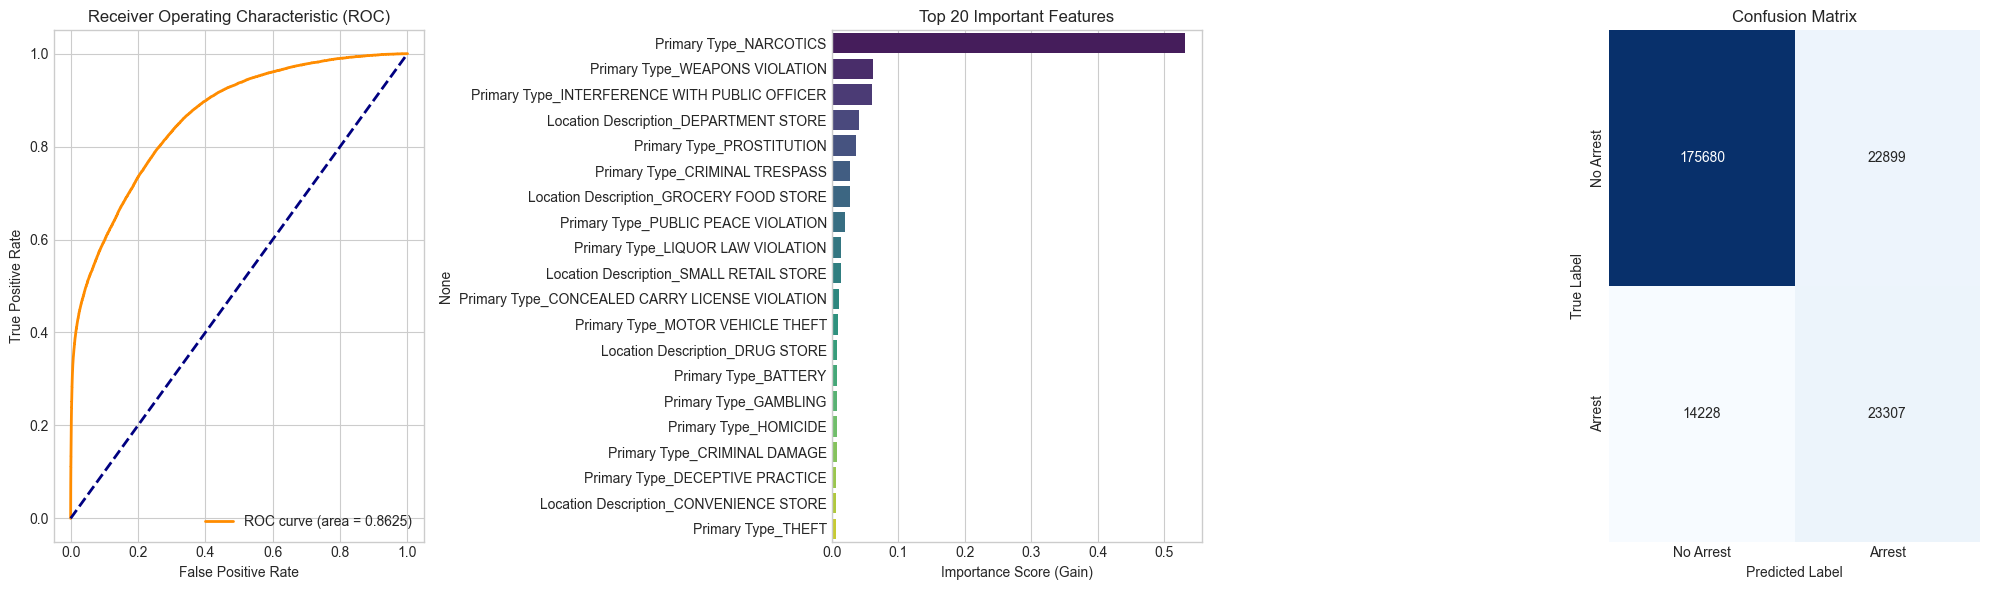

In [9]:
best_model_xgb = joblib.load('model_xgb.pkl')
plot_model_performance(best_model_xgb, X_test, y_test)

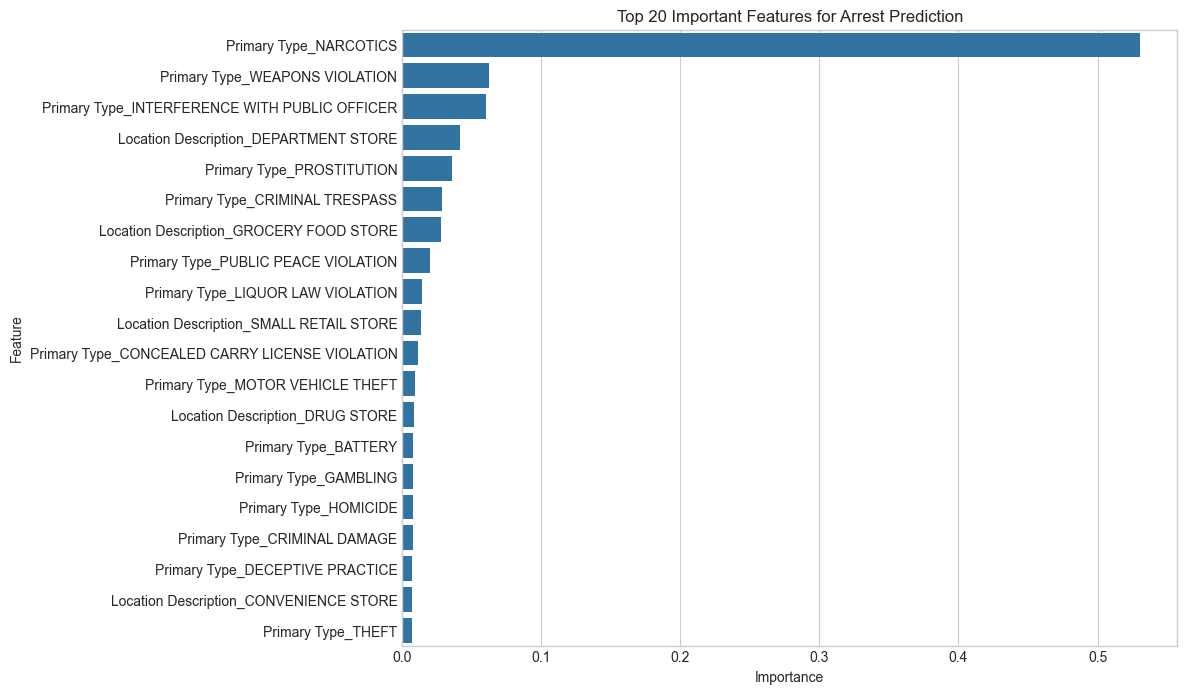

In [10]:
importances = best_model_xgb.feature_importances_
feature_names = X_train.columns 

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Important Features for Arrest Prediction')
plt.show()

In [11]:
booster = best_model_xgb.get_booster()

importance_gain = booster.get_score(importance_type='gain')

gain_df = pd.DataFrame(list(importance_gain.items()), columns=['Feature', 'Gain']).sort_values(by='Gain', ascending=False)
print(gain_df.head(10))

                                          Feature          Gain
27                         Primary Type_NARCOTICS  21566.103516
40                 Primary Type_WEAPONS VIOLATION   2527.494873
22  Primary Type_INTERFERENCE WITH PUBLIC OFFICER   2439.413330
49          Location Description_DEPARTMENT STORE   1695.139160
33                      Primary Type_PROSTITUTION   1460.005493
17                 Primary Type_CRIMINAL TRESPASS   1147.966064
52        Location Description_GROCERY FOOD STORE   1145.243164
35            Primary Type_PUBLIC PEACE VIOLATION    803.323914
25              Primary Type_LIQUOR LAW VIOLATION    572.305115
68        Location Description_SMALL RETAIL STORE    559.475464


In [13]:
# Clean before LightGBM
def clean_column_names(df):
    df.columns = [re.sub(r'[\[\]{}<>,:"]', '_', col) for col in df.columns]
    return df

X_train_gbm = clean_column_names(X_train)
X_test_gbm = clean_column_names(X_test)

X_train_gbm.columns = [col.replace(' ', '_') for col in X_train_gbm.columns]
X_test_gbm.columns = [col.replace(' ', '_') for col in X_test_gbm.columns]

print(X_train_gbm.columns.tolist())

['Domestic', 'Year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos', 'Primary_Type_ARSON', 'Primary_Type_ASSAULT', 'Primary_Type_BATTERY', 'Primary_Type_BURGLARY', 'Primary_Type_CONCEALED_CARRY_LICENSE_VIOLATION', 'Primary_Type_CRIM_SEXUAL_ASSAULT', 'Primary_Type_CRIMINAL_DAMAGE', 'Primary_Type_CRIMINAL_SEXUAL_ASSAULT', 'Primary_Type_CRIMINAL_TRESPASS', 'Primary_Type_DECEPTIVE_PRACTICE', 'Primary_Type_GAMBLING', 'Primary_Type_HOMICIDE', 'Primary_Type_HUMAN_TRAFFICKING', 'Primary_Type_INTERFERENCE_WITH_PUBLIC_OFFICER', 'Primary_Type_INTIMIDATION', 'Primary_Type_KIDNAPPING', 'Primary_Type_LIQUOR_LAW_VIOLATION', 'Primary_Type_MOTOR_VEHICLE_THEFT', 'Primary_Type_NARCOTICS', 'Primary_Type_NON-CRIMINAL', 'Primary_Type_OBSCENITY', 'Primary_Type_OFFENSE_INVOLVING_CHILDREN', 'Primary_Type_OTHER_NARCOTIC_VIOLATION', 'Primary_Type_OTHER_OFFENSE', 'Primary_Type_PROSTITUTION', 'Primary_Type_PUBLIC_INDECENCY', 'Primary_Type_PUBLIC_PEACE_VIOLATION', 'Prim

In [14]:
# LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,    
    max_depth=-1,         
    is_unbalance=True,    
    boosting_type='gbdt',
    device='cpu',       
    random_state=42,
    n_jobs=-1
)

# Early Stopping
lgbm_model.fit(
    X_train_gbm, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)
    ]
)

y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
print(f"LightGBM Test AUC: {roc_auc_score(y_test, y_prob_lgbm):.4f}")

[LightGBM] [Info] Number of positive: 522769, number of negative: 2272582
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048470 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 264
[LightGBM] [Info] Number of data points in the train set: 2795351, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.187014 -> initscore=-1.469532
[LightGBM] [Info] Start training from score -1.469532
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.851432	valid_0's binary_logloss: 0.380392
Early stopping, best iteration is:
[36]	valid_0's auc: 0.848909	valid_0's binary_logloss: 0.377501
LightGBM Test AUC: 0.8489


In [15]:
# Hyperparameter Tuning
param_dist = {
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 10, 20],
    'min_child_samples': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'colsample_bytree': [0.7, 0.8, 0.9], 
    'subsample': [0.7, 0.8, 0.9],       
}

lgbm_base = LGBMClassifier(
    n_estimators=500,     
    is_unbalance=True, 
    bagging_freq=5,   
    boosting_type='gbdt',
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=10,         
    scoring='roc_auc',
    cv=3,
    verbose=2,
    random_state=42
)

random_search.fit(X_train_gbm, y_train)

print(f"LGBM Best parameters: {random_search.best_params_}")
print(f"AUC: {random_search.best_score_:.4f}")

best_model_gbm = random_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Info] Number of positive: 348513, number of negative: 1515054
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036213 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 252
[LightGBM] [Info] Number of data points in the train set: 1863567, number of used features: 89
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.187014 -> initscore=-1.469531
[LightGBM] [Info] Start training from score -1.469531
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[CV] END colsample_bytree=0.8, learning_rate=0.1, max

In [17]:
y_prob_gbm_best = best_model_gbm.predict_proba(X_test_gbm)[:, 1]
y_pred_gbm_best = best_model_gbm.predict(X_test_gbm)
results['LightGBM'] = evaluate_model(y_test, y_pred_xgb_best, y_prob_gbm_best, 'LightGBM')

joblib.dump(best_model_gbm, 'model_gbm.pkl')
del X_train_gbm, y_train
gc.collect()

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5

  LightGBM
ROC-AUC:           0.8564
Average Precision: 0.6460
F1-macro:          0.7305

Classification Report:
              precision    recall  f1-score   support

   No Arrest       0.93      0.88      0.90    198579
      Arrest       0.50      0.62      0.56     37535

    accuracy                           0.84    236114
   macro avg       0.71      0.75      0.73    236114
weighted avg       0.86      0.84      0.85    236114



331

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5


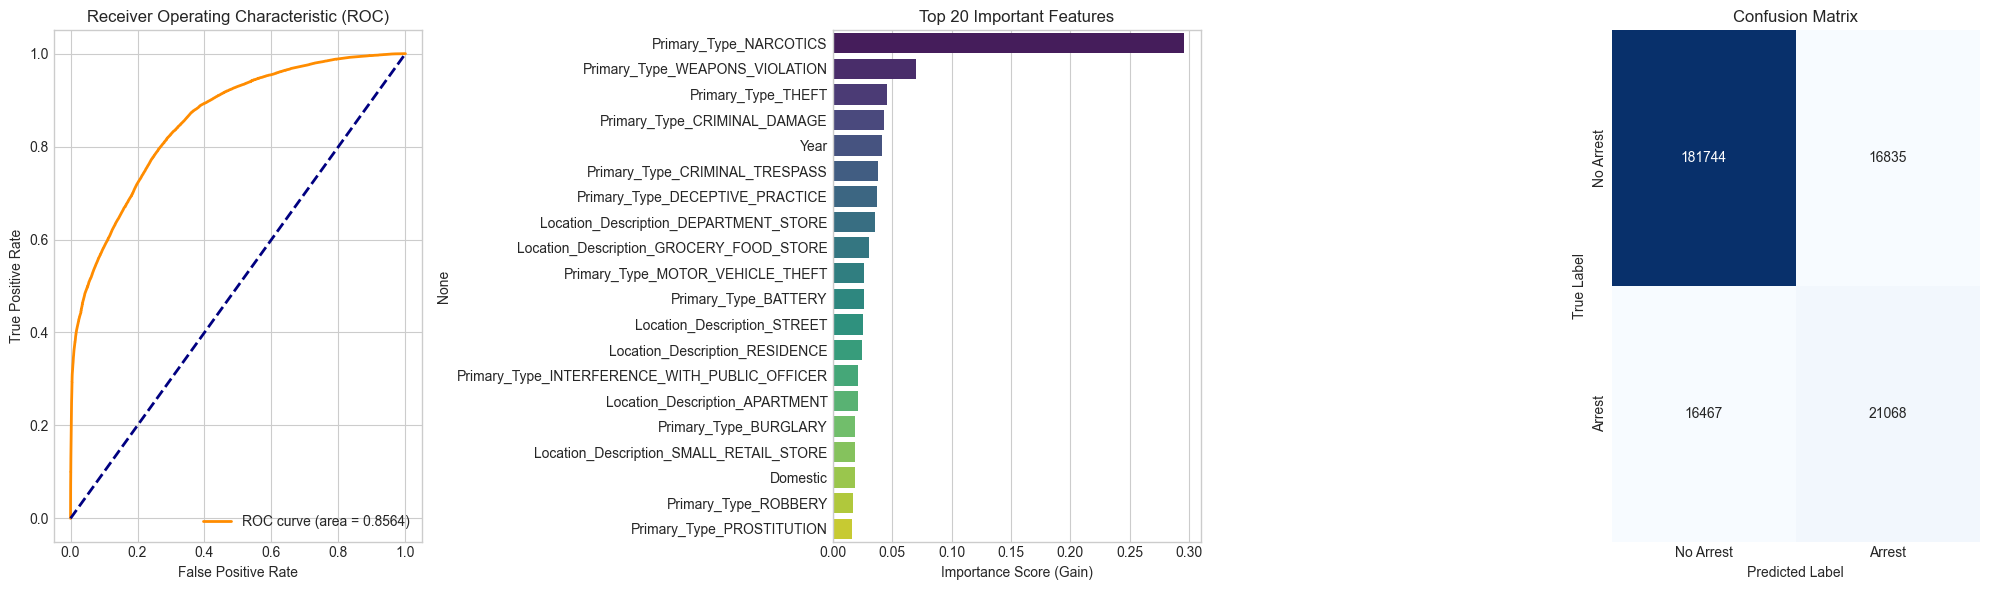

In [14]:
best_model_gbm = joblib.load('model_gbm.pkl')
plot_model_performance(best_model_gbm, X_test_gbm, y_test)